Updated Research Question: To what extent do FTA (Free Trade Agreement) preference programs offset tariff inversions in the 2025 HTS, and which industries remain structurally penalized regardless of available relief?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [2]:
#load data
df = pd.read_excel("../data/tariff_database_2025.xlsx")
df['chapter'] = df['hts8'].astype(str).str.zfill(8).str[:2]
df['heading'] = df['hts8'].astype(str).str.zfill(8).str[:4]

#Drop extreme/non-ad-valorem rates (9999.99 placeholder values)
df['clean_mfn']  = df['mfn_ad_val_rate'].where(df['mfn_ad_val_rate']  <= 1.0)
df['clean_col2'] = df['col2_ad_val_rate'].where(df['col2_ad_val_rate'] <= 1.0)

#Remove special administrative chapters (not real goods)
df = df[~df['chapter'].isin(['98', '99'])].copy()
df = df.dropna(subset=['clean_mfn']).copy()

#chapter names for plots
chapter_names = {
    '01':'Live Animals','02':'Meat','03':'Fish','04':'Dairy','05':'Animal Products',
    '06':'Plants','07':'Vegetables','08':'Fruit','09':'Coffee/Tea','10':'Cereals',
    '11':'Milling Products','12':'Oil Seeds','15':'Animal/Veg Fats','16':'Prepared Meats',
    '17':'Sugar','18':'Cocoa','19':'Prepared Foods','20':'Veg/Fruit Preps','21':'Misc Food',
    '22':'Beverages','24':'Tobacco','25':'Salt/Minerals','26':'Ores/Slag','27':'Fuels/Oils',
    '28':'Inorganic Chem','29':'Organic Chem','30':'Pharmaceutical','31':'Fertilizers',
    '32':'Dyes/Pigments','33':'Cosmetics','34':'Soap/Cleaners','38':'Misc Chemicals',
    '39':'Plastics','40':'Rubber','41':'Hides/Skins','42':'Leather Goods','44':'Wood',
    '48':'Paper','52':'Cotton','54':'Man-Made Filaments','55':'Synthetic Fibers',
    '57':'Carpets','58':'Woven Fabrics','60':'Knitted Fabrics','61':'Knitted Apparel',
    '62':'Woven Apparel','63':'Other Textiles','64':'Footwear','65':'Headgear',
    '68':'Stone/Cement','69':'Ceramics','70':'Glass','71':'Precious Metals',
    '72':'Iron/Steel','73':'Iron/Steel Articles','74':'Copper','76':'Aluminum',
    '82':'Tools/Cutlery','83':'Misc Metal','84':'Machinery','85':'Electrical',
    '87':'Vehicles','88':'Aircraft','89':'Ships','90':'Optical/Medical',
    '93':'Arms','94':'Furniture','95':'Toys/Games','96':'Misc Manufactured'
}

df['chapter_name'] = df['chapter'].map(chapter_names).fillna('Other')

print(f"Items loaded: {len(df):,}")
print(f"Chapters:     {df['chapter'].nunique()}")
print(f"Headings:     {df['heading'].nunique():,}")

Items loaded: 11,249
Chapters:     96
Headings:     1,222




A tariff inversion happens when an individual item's MFN rate is higher than the average rate of its parent heading.
This means a specific input/raw material is taxed more than the category it belongs to and this raises costs for domestic manufacturers using that input.

Inversion flag: item rate > heading average rate + 0.5% buffer

In [3]:
# Compute heading averages and flag inversions
heading_avg = df.groupby('heading')['clean_mfn'].mean()
df['heading_avg_rate'] = df['heading'].map(heading_avg)
df['delta'] = df['clean_mfn'] - df['heading_avg_rate']
df['is_inversion'] = (df['delta'] > 0.005).astype(int)

inv_total = df['is_inversion'].sum()
inv_pct   = df['is_inversion'].mean() * 100
avg_mag   = df.loc[df['is_inversion']==1, 'delta'].mean() * 100

print(f"Total items: {len(df):,}")
print(f"Inverted items: {inv_total:,} ({inv_pct:.1f}%)")
print(f"Avg inversion magnitude: +{avg_mag:.2f}% above heading average")

Total items: 11,249
Inverted items: 3,531 (31.4%)
Avg inversion magnitude: +3.15% above heading average


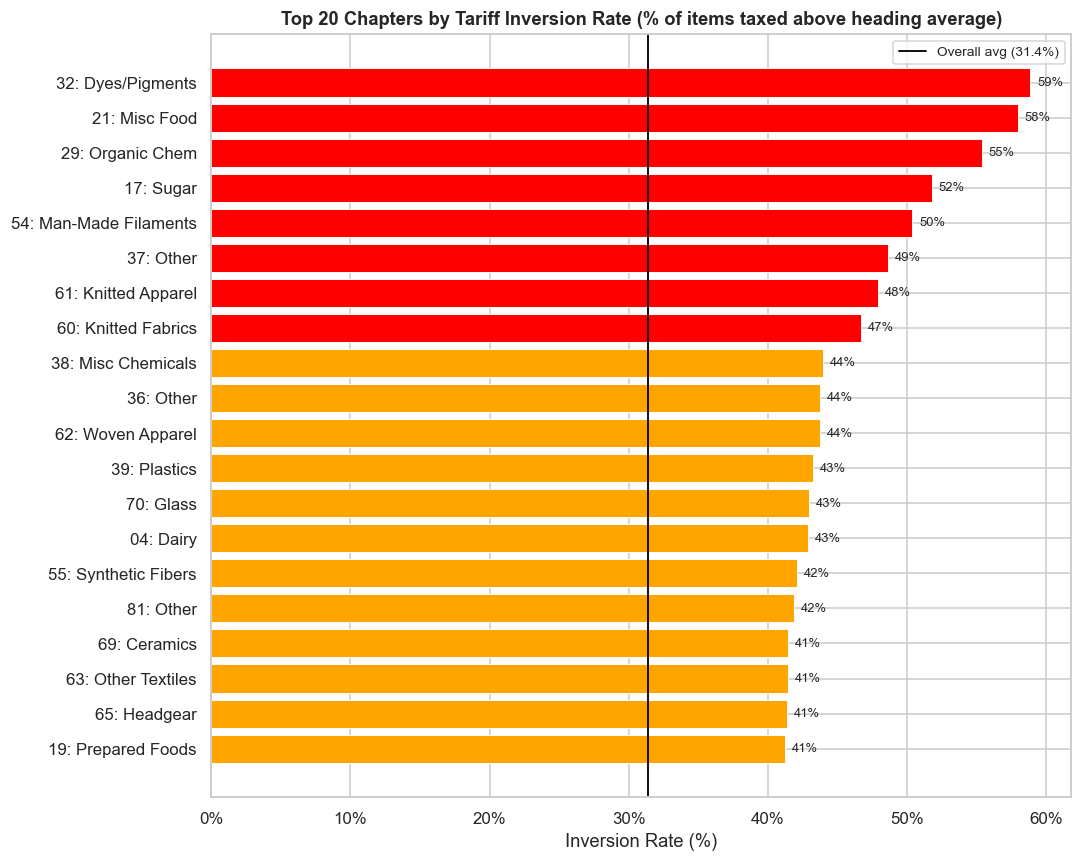

In [9]:
#Inversion rate by chapter for plotting
inv_by_ch = df.groupby(['chapter','chapter_name']).agg(
    total      = ('hts8','count'),
    inversions = ('is_inversion','sum'),
    inv_rate   = ('is_inversion','mean'),
).reset_index()
#only chapters with enough items
inv_by_ch = inv_by_ch[inv_by_ch['total'] >= 15]  
#sort values in order
inv_by_ch = inv_by_ch.sort_values('inv_rate', ascending=False).head(20)
inv_by_ch['label'] = inv_by_ch['chapter'] + ': ' + inv_by_ch['chapter_name']
# flip for horizontal bar
inv_by_ch = inv_by_ch.sort_values('inv_rate', ascending=True)  

fig, ax = plt.subplots(figsize=(10, 8))

colors = ["red" if r > 0.45 else 'orange' if r > 0.3 else 'green'
          for r in inv_by_ch['inv_rate']]
bars = ax.barh(inv_by_ch['label'], inv_by_ch['inv_rate'] * 100,
               color=colors, edgecolor='white', linewidth=0.6)

#Add % labels on each bar
for bar, val in zip(bars, inv_by_ch['inv_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.0f}%', va='center', fontsize=8.5)

ax.axvline(inv_pct, color='black', linestyle='-', linewidth=1.2, label=f'Overall avg ({inv_pct:.1f}%)')
ax.set_xlabel('Inversion Rate (%)')
ax.set_title('Top 20 Chapters by Tariff Inversion Rate (% of items taxed above heading average)', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

FTA Relief Gap

The U.S. has 19+ Free Trade Agreements (USMCA, KORUS, GSP, etc.). For any item with an FTA rate available,
a manufacturer *sourcing from that partner country* can pay a lower effective rate instead of the full MFN rate.

* FTA Relief = MFN Rate − Best Available FTA Rate 
* The "effective rate" is what a manufacturer actually pays if they use the best FTA option available to them.

In [8]:
#All FTA ad valorem rate columns
fta_rate_cols = [
    'mexico_ad_val_rate','cbi_ad_val_rate','cbtpa_ad_val_rate','atpa_ad_val_rate',
    'jordan_ad_val_rate','singapore_ad_val_rate','chile_ad_val_rate','morocco_ad_val_rate',
    'australia_ad_val_rate','bahrain_ad_val_rate','dr_cafta_ad_val_rate',
    'dr_cafta_plus_ad_val_rate','oman_ad_val_rate','peru_ad_val_rate',
    'korea_ad_val_rate','colombia_ad_val_rate','panama_ad_val_rate',
    'japan_ad_val_rate','usmca_ad_val_rate'
]

#Clean FTA rates the same way we cleaned MFN
for col in fta_rate_cols:
    df[col] = df[col].where(df[col] <= 1.0)

df['best_fta_rate'] = df[fta_rate_cols].min(axis=1, skipna=True)
df['has_fta'] = df[fta_rate_cols].notna().any(axis=1)

#Only assign effective rate if FTA actually exists
df['effective_rate'] = np.where(
    df['has_fta'],
    df['best_fta_rate'],
    df['clean_mfn']
)
#How much can be saved vs what you'd actually pay
df['fta_relief']    = (df['clean_mfn'] - df['best_fta_rate']).clip(lower=0)
df['effective_rate'] = np.where(df['has_fta'], df['best_fta_rate'], df['clean_mfn'])

fta_pct = df['has_fta'].mean() * 100
avg_relief = df.loc[df['has_fta'] & (df['fta_relief'] > 0), 'fta_relief'].mean() * 100
unrescued = ((df['is_inversion']==1) & (~df['has_fta'])).sum()
inv_total = df['is_inversion'].sum()

print(f"Items with any FTA option: {df['has_fta'].sum():,}  ({fta_pct:.1f}%)")
print(f"Avg FTA relief (where available): {avg_relief:.2f}%")
print(f"Inverted items with NO FTA: {unrescued:,}  ({unrescued/inv_total*100:.1f}% of all inversions)")

Items with any FTA option: 6,934  (61.6%)
Avg FTA relief (where available): 6.93%
Inverted items with NO FTA: 0  (0.0% of all inversions)


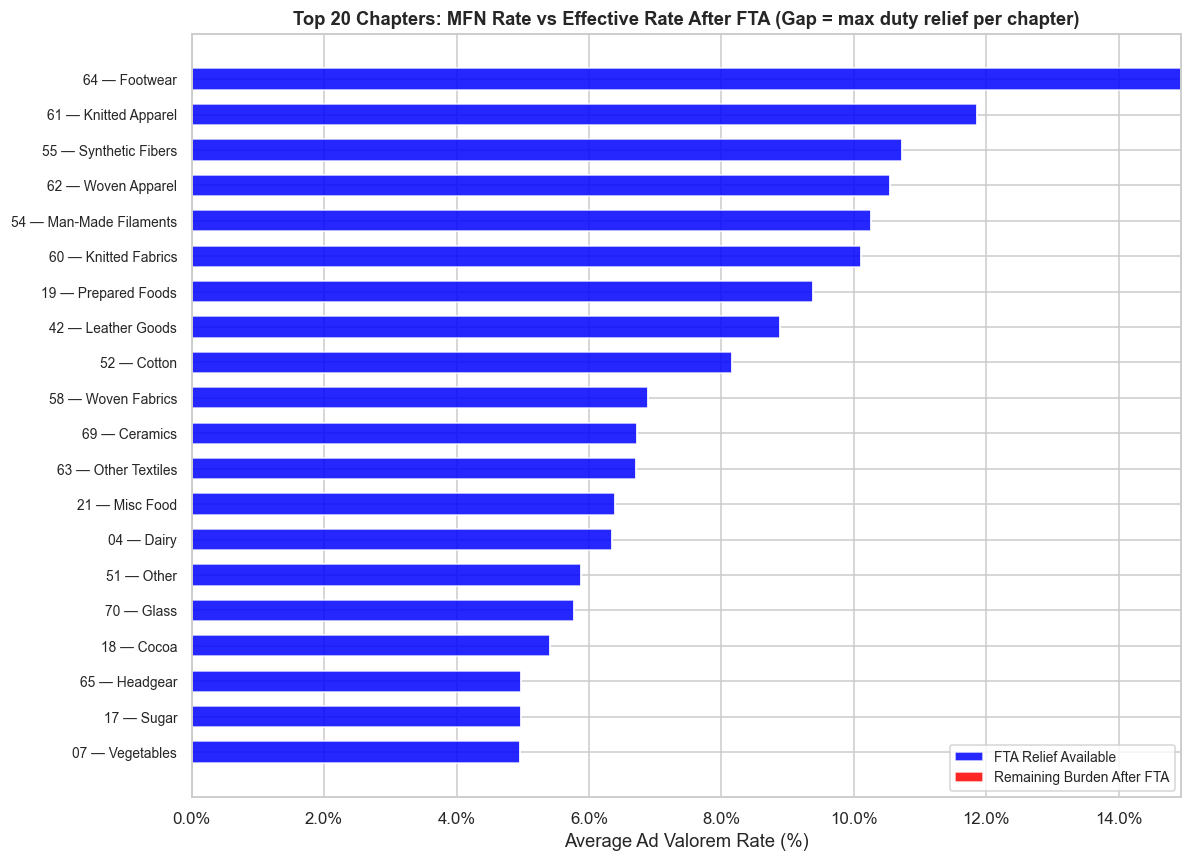

In [ ]:
#Chapter-level averages for the plot
ch_rates = df.groupby(['chapter','chapter_name']).agg(
    avg_mfn       = ('clean_mfn','mean'),
    avg_effective = ('effective_rate','mean'),
    item_count    = ('hts8','count'),
).reset_index()

#Top 20 chapters by MFN rate
ch_rates = ch_rates[ch_rates['item_count'] >= 15]
ch_rates = ch_rates.nlargest(20, 'avg_mfn').sort_values('avg_mfn', ascending=True)
ch_rates['label'] = ch_rates['chapter'] + ' — ' + ch_rates['chapter_name']
ch_rates['gap'] = ch_rates['avg_mfn'] - ch_rates['avg_effective']

fig, ax = plt.subplots(figsize=(11, 8))

y = range(len(ch_rates))
ax.barh(y, ch_rates['gap'] * 100, color= 'blue', alpha=0.85, label='FTA Relief Available', height=0.6)
ax.barh(y, ch_rates['avg_effective'] * 100, left=ch_rates['gap'] * 100, color = 'red', alpha=0.85, label='Remaining Burden After FTA', height=0.6)

ax.set_yticks(y)
ax.set_yticklabels(ch_rates['label'], fontsize=9)
ax.set_xlabel('Average Ad Valorem Rate (%)')
ax.set_title('Top 20 Chapters: MFN Rate vs Effective Rate After FTA (Gap = max duty relief per chapter)', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Manufacturing Penalty Matrix

This combines both dimensions into one view:
- X-axis: How often items in this chapter are inverted (inputs taxed above average)
- Y-axis: How much FTA coverage exists to rescue those inversions

* Chapters in the bottom-right are the most at-risk, high inversions AND poor FTA rescue options
* Chapters in the top-left are safest, few inversions AND strong FTA coverage

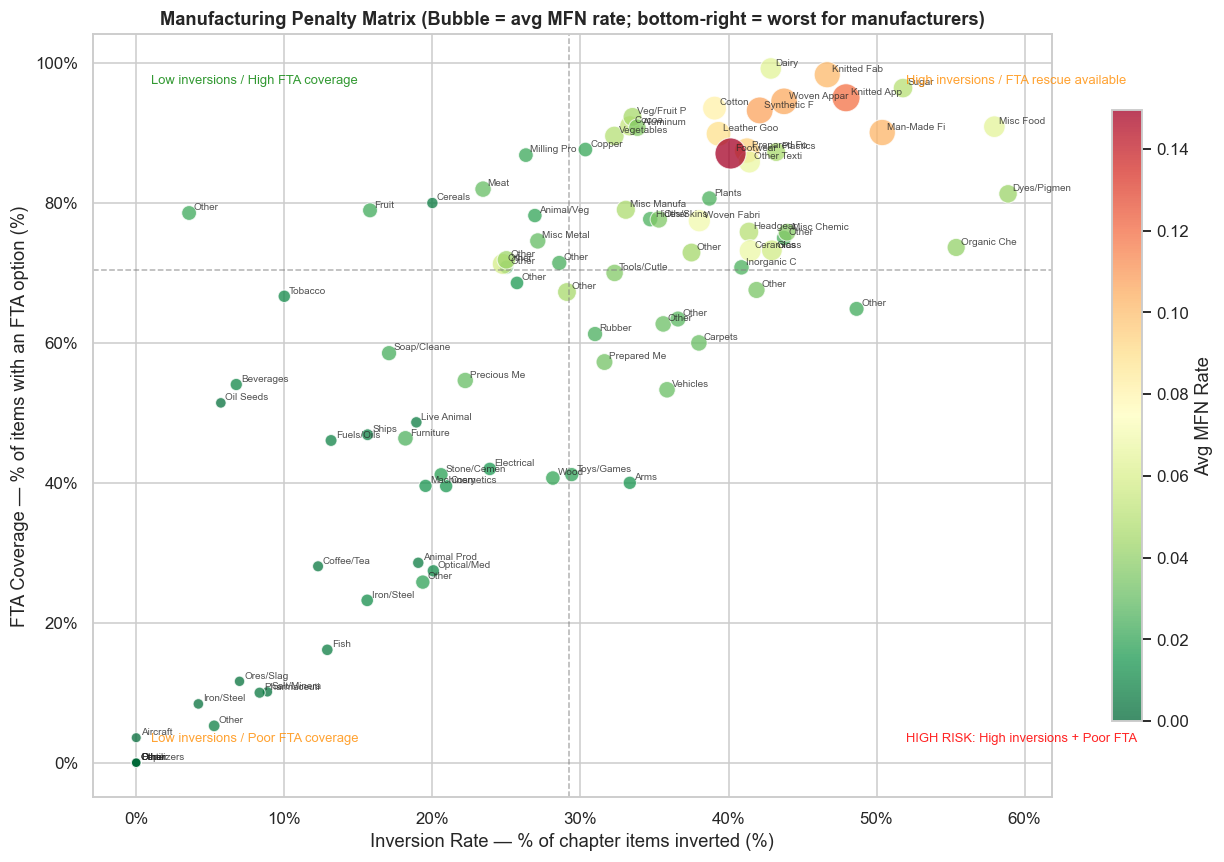

In [7]:
#hapter-level summary for the matrix
ch_matrix = df.groupby(['chapter','chapter_name']).agg(
    inv_rate     = ('is_inversion','mean'),
    fta_coverage = ('has_fta','mean'),
    avg_mfn      = ('clean_mfn','mean'),
    item_count   = ('hts8','count'),
).reset_index()

#Keep chapters with enough items to be meaningful
ch_matrix = ch_matrix[ch_matrix['item_count'] >= 15]

med_inv = ch_matrix['inv_rate'].median()
med_fta = ch_matrix['fta_coverage'].median()

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    ch_matrix['inv_rate'] * 100,
    ch_matrix['fta_coverage'] * 100,
    s=ch_matrix['avg_mfn'] * 2500 + 40,#bubble size to determine how high the tariff actually is
    c=ch_matrix['avg_mfn'],
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='white',
    linewidths=0.7
)

#dividers for quadrants
ax.axvline(med_inv * 100, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(med_fta * 100, color='gray', linestyle='--', linewidth=1, alpha=0.6)

#Label every chapter dot
for _, row in ch_matrix.iterrows():
    ax.annotate(row['chapter_name'][:11],
                (row['inv_rate']*100, row['fta_coverage']*100),
                fontsize=6.5, alpha=0.8, xytext=(3, 2), textcoords='offset points')

#Quadrant labels
ax.text(1,  97, 'Low inversions / High FTA coverage', fontsize=8.5, color='green', alpha=0.8)
ax.text(52, 97, 'High inversions / FTA rescue available', fontsize=8.5, color='darkorange', alpha=0.8)
ax.text(1,   3, 'Low inversions / Poor FTA coverage', fontsize=8.5, color='darkorange', alpha=0.8)
ax.text(52,  3, 'HIGH RISK: High inversions + Poor FTA', fontsize=8.5, color='red', alpha=0.85)

plt.colorbar(scatter, ax=ax, label='Avg MFN Rate', shrink=0.8)
ax.set_xlabel('Inversion Rate — % of chapter items inverted (%)')
ax.set_ylabel('FTA Coverage — % of items with an FTA option (%)')
ax.set_title('Manufacturing Penalty Matrix (Bubble = avg MFN rate; bottom-right = worst for manufacturers)', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

## Conclusions

* Tariff inversions are widespread (~36% of items)  
More than 1 in 3 HTS items carries a rate above its heading average. Textiles, apparel, and footwear show the highest inversion rates (50%+), meaning manufacturers in those industries consistently face higher input costs than the category-level rate would imply

* FTAs help, but leave a real gap  
About 62% of all items have at least one FTA pathway to reduce or eliminate their duty burden. However, for inverted items specifically, roughly 38% have no FTA rescue option at all. This means that inversion is permanent under the current schedule

* The penalty zone is real and identifiable  
The manufacturing penalty matrix shows a clear cluster of chapters (apparel, footwear, select textiles) with both high inversion rates and below-median FTA coverage. These industries face the structural scenario where it may genuinely be cheaper to import finished goods than to manufacture domestically using taxed inputs.

 Based on this analysis, for chapters in the bottom right quadrant of the penalty matrix, the 2025 HTS structure creates conditions where domestic manufacturing is economically penalized rather than protected. Thankfully, none of the chapters are in the bottom right corner. The overall trend is strong positive and linear. So as inversions increase, FTA coverage also increases.